<a href="https://colab.research.google.com/github/Wasey23/CI-345-Machine-Learning-Project/blob/main/XGBoost_Enhanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Reading Dataset and Basic Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

tmbd = pd.read_csv('tmdb_movies_data.csv')
tmbd.head(5)


,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/2015,5562,6.5,2015,137999939.3,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/2015,6185,7.1,2015,137999939.3,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/2015,2480,6.3,2015,101199955.5,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/2015,5292,7.5,2015,183999919.0,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/2015,2947,7.3,2015,174799923.1,1.385749e+09


In [2]:
tmbd.isnull().sum()

,0
id,0
imdb_id,10
popularity,0
budget,0
revenue,0
original_title,0
cast,76
homepage,7930
director,44
tagline,2824


In [3]:
tmbd.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


## Data Preprocessing

### 0. Copying Dataset

In [4]:
tmbd_processed = tmbd.copy()

In [5]:
tmbd_processed.duplicated().sum()
duplicate = tmbd_processed[tmbd_processed.duplicated()]
duplicate

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
2090,42194,tt0411951,0.59643,30000000,967000,TEKKEN,Jon Foo|Kelly Overton|Cary-Hiroyuki Tagawa|Ian...,NaN,Dwight H. Little,Survival is no game,...,"In the year of 2039, after World Wars destroy ...",92,Crime|Drama|Action|Thriller|Science Fiction,Namco|Light Song Films,3/20/2010,110,5.0,2010,30000000.0,967000.0


In [7]:
tmbd_processed.drop_duplicates(inplace=True)
tmbd_processed.duplicated().sum()

np.int64(0)

### 1. Feature Engineering


#### 1a. The target variable will need to be made, where we assume that a movie is a box-office "hit" when the revenue is double that of the budget, i.e, tmbd['revenue'] > tmbd['budget'] * 2

In [6]:
tmbd_processed['is_hit'] = (tmbd_processed['revenue'] > tmbd_processed['budget'] * 2).astype(int)
print(tmbd_processed['is_hit'].value_counts())

is_hit
0    7850
1    3016
Name: count, dtype: int64


In [7]:
print(f'''Movie is hit: {tmbd_processed['is_hit'].value_counts()[1]}
Movie is flop: {tmbd_processed['is_hit'].value_counts()[0]}''')


Movie is hit: 3016
Movie is flop: 7850


#### 1b. Making a feature "release_month" from the given feature "release_date"
to ease classification

In [8]:
tmbd_processed['release_month'] = pd.to_datetime(tmbd_processed['release_date']).dt.month
tmbd_processed.drop(['release_date'], axis=1, inplace=True, errors = 'ignore')

In [9]:
tmbd_processed.drop('release_year', axis=1, inplace=True)

In [10]:
tmbd_processed.head(5)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,vote_count,vote_average,budget_adj,revenue_adj,is_hit,release_month
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,137999939.3,1.392446e+09,1,6
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,6185,7.1,137999939.3,3.481613e+08,1,5
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,2480,6.3,101199955.5,2.716190e+08,1,3
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,5292,7.5,183999919.0,1.902723e+09,1,12
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,2947,7.3,174799923.1,1.385749e+09,1,4


### 2. Filtering


 #### 2a. columns like budget and revenue have 0 recorded more than 50% of the time. We have to filter out those movies where budget and revenue are 0 as we can't use them to train our classifier.

In [11]:
# Filtering budget = 0 and revenue = 0 columns
tmbd_processed = tmbd_processed[(tmbd_processed['budget']>0) & (tmbd_processed['revenue']>0)].copy()
tmbd_processed.isnull().sum()

,0
id,0
imdb_id,0
popularity,0
budget,0
revenue,0
original_title,0
cast,4
homepage,2429
director,1
tagline,280


#### 2b. We filter out rows with a run time more than 240 minutes and less than 60 minutes as those aren't traditional movies.

In [13]:
tmbd_processed = tmbd_processed[(tmbd_processed['runtime']<=240) & (tmbd_processed['runtime']>=60)]
print(f'Standard Movies: {len(tmbd_processed)}')

Standard Movies: 3850


### 3. Encoding

We use One-Hot Encoding to encode the 'genres' column. A column will be made for each genre. We will use
.str.get_dummies to encode all genres in their separate columns. We will then concatenate all these columns to our processed dataset. We will also drop the original column of genres.

In [14]:
# Using sep = '|' as we need to separate each genre
genres_encoded = tmbd_processed['genres'].str.get_dummies(sep='|')

# Concatenating the encoded columns to our processed dataset
tmbd_processed = pd.concat([tmbd_processed, genres_encoded], axis=1)

# dropping 'genres' column as it's no longer needed
tmbd_processed.drop('genres', axis=1, inplace=True)

tmbd_processed.head(5)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,0,0,0,0,0,1,0,1,0,0
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,0,0,0,0,0,1,0,1,0,0
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,0,0,0,0,0,1,0,1,0,0
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,0,0,0,0,0,1,0,0,0,0
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,0,0,0,0,0,0,0,1,0,0


### 4. Dropping columns


#### 4a. Text heavy columns like homepage, tagline etc. have a lot of null values to be useful for the classifier. Columns that have too many unique values (high-cardinality) will also be dropped to make a working baseline model.

In [15]:
# Re-calculating counts from the source to ensure visibility even after dropping
categorical_cols = tmbd_processed.select_dtypes(exclude=['number']).columns
unique_counts = tmbd_processed[(tmbd_processed['budget']>0) & (tmbd_processed['revenue']>0)][categorical_cols].nunique().sort_values(ascending=False).to_dict()

print("Number of unique values per categorical column:")
for column, count in unique_counts.items():
    print(f"{column}: {count}")

Number of unique values per categorical column:
imdb_id: 3849
overview: 3849
cast: 3824
original_title: 3803
keywords: 3653
tagline: 3556
production_companies: 3005
director: 1710
homepage: 1401


In [16]:
# Dropping columns using the keys from our unique_counts dictionary
# Adding errors='ignore' prevents a KeyError if the cell is run multiple times
tmbd_processed.drop(list(unique_counts.keys()), axis=1, inplace=True, errors='ignore')

#### 4b. To prevent data leakage and overfitting columns like id, revenue and revenue_adj should be removed.

In [17]:
tmbd_processed.drop(['id', 'revenue', 'revenue_adj'], axis=1, inplace=True)

In [18]:
# Check the remaining columns and null counts
print("Remaining columns, with their null values:")
display(tmbd_processed.isnull().sum())

Remaining columns, with their null values:


,0
popularity,0
budget,0
runtime,0
vote_count,0
vote_average,0
budget_adj,0
is_hit,0
release_month,0
Action,0
Adventure,0


In [19]:
# Final Processed dataset shape
print(f'''Original Dataset shape: {tmbd.shape}
Processed Dataset shape: {tmbd_processed.shape}''')


Original Dataset shape: (10866, 21)
Processed Dataset shape: (3850, 28)


## Separating Features

We will define Features(X) and target(y) before proceeding to train-test split

In [20]:
# Defining Features (X) and target (y)
# Dropping is_hit from Features
X = tmbd_processed.drop('is_hit', axis=1)
# Defining target as is_hit
y = tmbd_processed['is_hit']


## Train-Test Split (80/20)

We have to split the dataset up in training and testing for model evaluation, we will employ a 80-20 split for this project.


In [21]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training features shape: {X_train.shape}')
print(f'Training target shape: {y_train.shape}')
print(f'Testing features shape: {X_test.shape}')
print(f'Testing target shape: {y_test.shape}')

Training features shape: (3080, 27)
Training target shape: (3080,)
Testing features shape: (770, 27)
Testing target shape: (770,)


## Feature Scaling

We ensure that we fit and transform the training data. Also, we ensure that the testing data isn't fitted, it's very important

In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# FIT to training data and TRANSFORM the training data
X_train_scaled = scaler.fit_transform(X_train)

# Only TRANSFORM the testing data
X_test_scaled = scaler.transform(X_test)

## Training XGBoost Model

In [23]:
print(f'Filtered flop movies: {tmbd_processed['is_hit'].value_counts().loc[0]}')
print(f'Filtered hit movies: {tmbd_processed['is_hit'].value_counts().loc[1]}')

Filtered flop movies: 1830
Filtered hit movies: 2020


In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


XGB = XGBClassifier(random_state=42,
                    eval_metric='logloss'
                    )

# Training the model
XGB.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Testing the Model (Baseline)

In [25]:
y_pred  = XGB.predict(X_test_scaled)

print('Confusion Matrix')
print(confusion_matrix(y_test, y_pred))
print('Classification Report')
print(classification_report(y_test, y_pred, digits=3, target_names=['Flop', 'Hit']))

Confusion Matrix
[[260 112]
 [116 282]]
Classification Report
              precision    recall  f1-score   support

        Flop      0.691     0.699     0.695       372
         Hit      0.716     0.709     0.712       398

    accuracy                          0.704       770
   macro avg      0.704     0.704     0.704       770
weighted avg      0.704     0.704     0.704       770



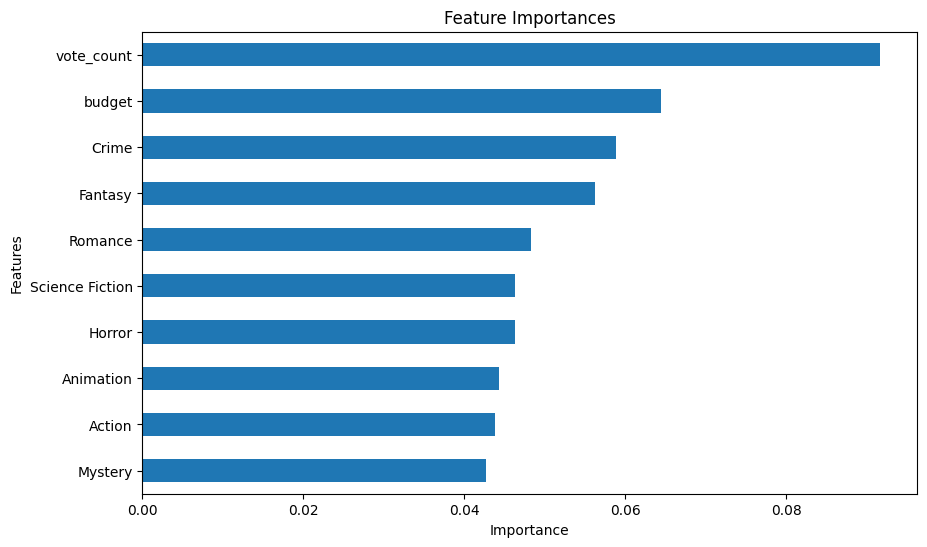

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(XGB.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 6))
importances.nlargest(10).sort_values().plot(kind='barh')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

XGB_Enhanced = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(estimator=XGB_Enhanced,
                           param_grid = param_grid,
                           cv=3,
                           scoring='accuracy',
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print(f'Best Parameters: {grid_search.best_params_}')

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print('Confusion Matrix')
print(confusion_matrix(y_test, y_pred_best))
print('Classification Report')
print(classification_report(y_test, y_pred_best, digits=3, target_names=['Flop', 'Hit']))

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Confusion Matrix
[[264 108]
 [ 95 303]]
Classification Report
              precision    recall  f1-score   support

        Flop      0.735     0.710     0.722       372
         Hit      0.737     0.761     0.749       398

    accuracy                          0.736       770
   macro avg      0.736     0.735     0.736       770
weighted avg      0.736     0.736     0.736       770

